In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


In [2]:
uploads = files.upload()


Saving KingCrimson.jpg to KingCrimson.jpg


array([[ 15,  58,  70, ..., 112, 116, 120],
       [  6,  64,  78, ..., 118, 119, 119],
       [  8,  46,  68, ..., 118, 116, 113],
       ...,
       [  1,   2,  20, ...,  60,  56,  57],
       [  3,   4,  26, ...,  63,  58,  57],
       [  4,   8,  33, ...,  62,  56,  54]], dtype=uint8)
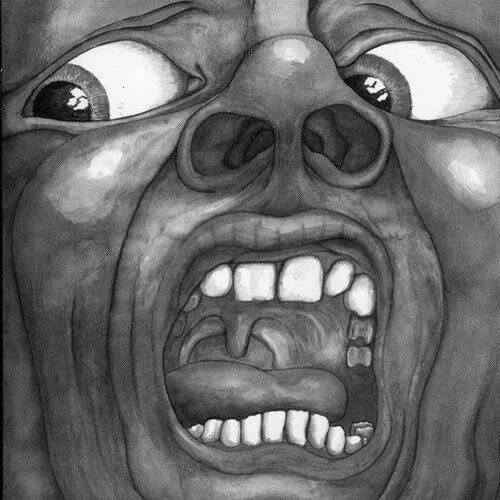

In [4]:
img = cv2.imread('KingCrimson.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_gray


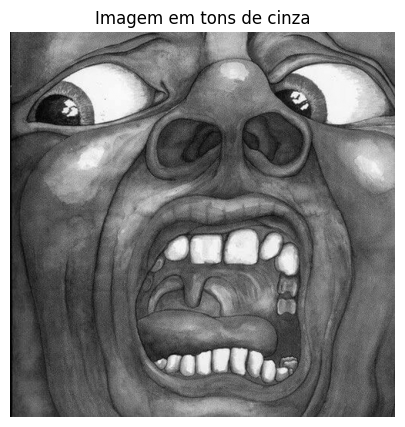

In [5]:
plt.figure(figsize = (8,5))
plt.imshow(img_gray, cmap = 'gray')
plt.title('Imagem em tons de cinza')
plt.axis('off')
plt.show()

In [6]:
def quantizar(img, bits):
    descarte = 8 - bits
    img_quant = (img.astype(np.uint16) >> descarte) << descarte
    return img_quant.astype(np.uint8)

In [7]:
img_1bit = quantizar(img_gray, 1)
img_2bit = quantizar(img_gray, 2)
img_4bit = quantizar(img_gray, 4)
img_8bit = quantizar(img_gray, 8)


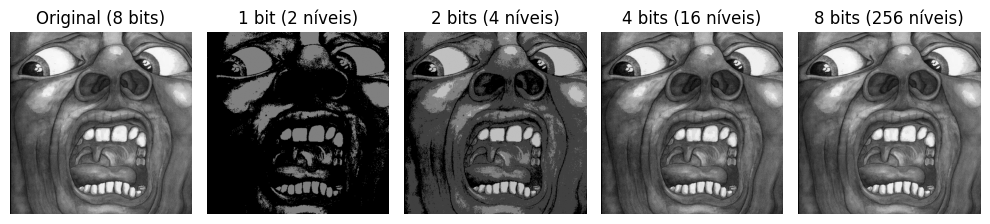

In [8]:
fig, ax = plt.subplots(1, 5, figsize=(10,4))

ax[0].imshow(img_gray, cmap = 'gray', vmin=0, vmax=255)
ax[0].set_title('Original (8 bits)')
ax[0].axis('off')

ax[1].imshow(img_1bit, cmap = 'gray', vmin=0, vmax=255)
ax[1].set_title('1 bit (2 níveis)')
ax[1].axis('off')

ax[2].imshow(img_2bit, cmap = 'gray', vmin=0, vmax=255)
ax[2].set_title('2 bits (4 níveis)')
ax[2].axis('off')

ax[3].imshow(img_4bit, cmap = 'gray', vmin=0, vmax=255)
ax[3].set_title('4 bits (16 níveis)')
ax[3].axis('off')

ax[4].imshow(img_8bit, cmap = 'gray', vmin=0, vmax=255)
ax[4].set_title('8 bits (256 níveis)')
ax[4].axis('off')

plt.tight_layout()
fig.savefig('quantizacao.png')
plt.show()

**O que acontece com os detalhes e com as transições de intensidade da imagem à
medida que reduzimos o número de bits?**

Reduzir o número de bits de uma imagem diminui a quantidade de tons disponíveis por pixel, o que causa perda de detalhes finos e gera faixas visíveis nas transições de cor. Exemplo:
Perda de texturas: Cores e tons muito parecidos viram um único valor sólido.
Fim da suavidade: Os gradientes (passagens de claro para escuro) deixam de ser contínuos.